Nama Lengkap : Nazarul Bagus Riyadi

NIM : 240401010229

Kelas : IF404

---

# Praktikum Pertemuan 5: Visualisasi Data


## Langkah 1: Load & Inspect Dataset

Muat dataset **Tips** dari Seaborn. Dataset ini berisi 244 transaksi restoran dengan informasi tagihan, tip, hari, waktu makan, gender, dan status perokok.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

df = sns.load_dataset('tips')
print('=' * 50)
print(f'Shape dataset: {df.shape}')
print(f'\nTipe data:\n{df.dtypes}')
print(f'\nStatistik deskriptif:\n{df.describe().round(2)}')
print('=' * 50)


Shape dataset: (244, 7)

Tipe data:
total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

Statistik deskriptif:
       total_bill     tip    size
count      244.00  244.00  244.00
mean        19.79    3.00    2.57
std          8.90    1.38    0.95
min          3.07    1.00    1.00
25%         13.35    2.00    2.00
50%         17.80    2.90    2.00
75%         24.13    3.56    3.00
max         50.81   10.00    6.00


**Interpretasi Langkah 1:** Dataset terdiri dari 244 baris dan 7 kolom. Kolom numerik: `total_bill`, `tip`, dan `size`. Kolom kategorik: `sex`, `smoker`, `day`, `time`. Data siap divisualisasikan.


## Langkah 2: Dashboard Visualisasi Statis (6 Grafik)

Membuat dashboard 2×3 menggunakan `GridSpec` dengan 6 jenis grafik:
1. **Bar chart** — perbandingan rata-rata tagihan per hari
2. **Histogram + KDE** — distribusi tagihan per waktu makan
3. **Violin plot** — distribusi tagihan per hari & gender
4. **Boxplot** — distribusi tip per hari
5. **Scatter plot** — hubungan tagihan vs tip
6. **Stacked bar** — komposisi perokok per hari


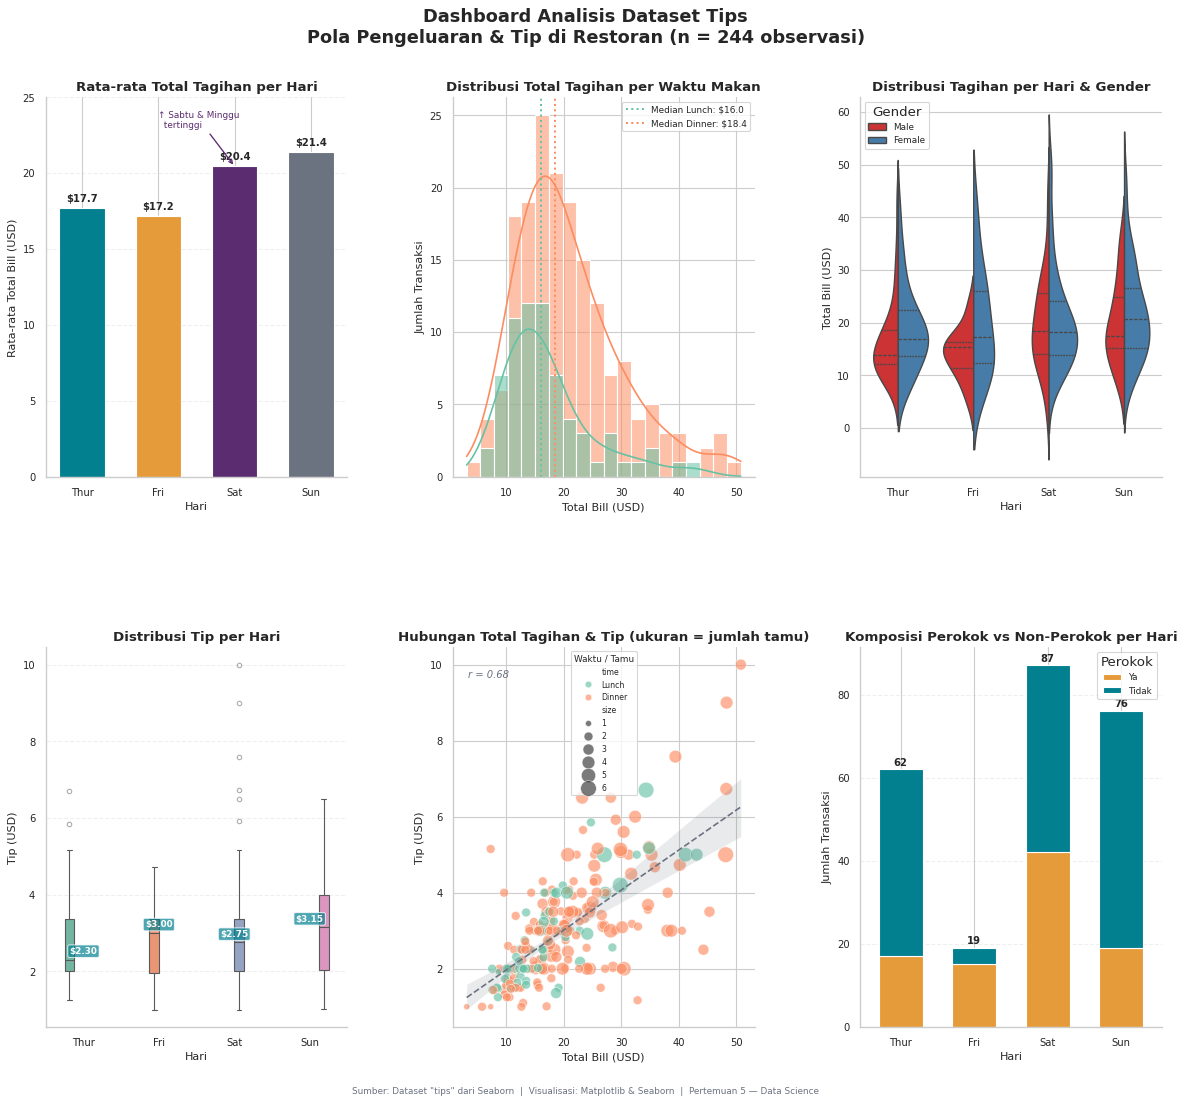

In [2]:
print(f"Shape dataset: {df.shape}")
print(f"\nTipe data:\n{df.dtypes}")
print(f"\nStatistik deskriptif:\n{df.describe().round(2)}")

# ── 2. SETUP GLOBAL STYLE ─────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})

COLORS = {
    'teal':   '#028090',
    'amber':  '#E69B3A',
    'purple': '#5B2C6F',
    'gray':   '#6B7280',
}

# ── 3. SETUP FIGURE LAYOUT ────────────────────────────────────────────
fig = plt.figure(figsize=(18, 14))
fig.suptitle(
    'Dashboard Analisis Dataset Tips\n'
    'Pola Pengeluaran & Tip di Restoran (n = 244 observasi)',
    fontsize=16, fontweight='bold', y=0.98
)

gs = gridspec.GridSpec(
    2, 3, figure=fig,
    hspace=0.45, wspace=0.35,
    top=0.90, bottom=0.07
)

ax1 = fig.add_subplot(gs[0, 0])   # Bar chart
ax2 = fig.add_subplot(gs[0, 1])   # Histogram + KDE
ax3 = fig.add_subplot(gs[0, 2])   # Violin plot
ax4 = fig.add_subplot(gs[1, 0])   # Boxplot
ax5 = fig.add_subplot(gs[1, 1])   # Scatter plot
ax6 = fig.add_subplot(gs[1, 2])   # Stacked bar (komposisi)

# ─────────────────────────────────────────────────────────────────────
# GRAFIK 1 — Bar Chart: Rata-rata Tagihan per Hari
# ─────────────────────────────────────────────────────────────────────
day_order = ['Thur', 'Fri', 'Sat', 'Sun']
avg_by_day = df.groupby('day', observed=False)['total_bill'].mean().reindex(day_order)

bars = ax1.bar(
    avg_by_day.index, avg_by_day.values,
    color=[COLORS['teal'], COLORS['amber'], COLORS['purple'], COLORS['gray']],
    edgecolor='white', width=0.6
)
ax1.bar_label(bars, fmt='$%.1f', padding=4, fontsize=9, fontweight='bold')
ax1.set_title('Rata-rata Total Tagihan per Hari')
ax1.set_xlabel('Hari')
ax1.set_ylabel('Rata-rata Total Bill (USD)')
ax1.set_ylim(0, 25)
ax1.spines[['top', 'right']].set_visible(False)
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# Anotasi insight
ax1.annotate(
    '↑ Sabtu & Minggu\n  tertinggi',
    xy=('Sat', avg_by_day['Sat']),
    xytext=('Fri', 23),
    fontsize=8, color=COLORS['purple'],
    arrowprops=dict(arrowstyle='->', color=COLORS['purple'], lw=1.2)
)

# ─────────────────────────────────────────────────────────────────────
# GRAFIK 2 — Histogram + KDE: Distribusi Total Tagihan per Waktu Makan
# ─────────────────────────────────────────────────────────────────────
sns.histplot(
    data=df, x='total_bill', hue='time',
    kde=True, palette='Set2', alpha=0.55,
    bins=20, ax=ax2
)
ax2.set_title('Distribusi Total Tagihan per Waktu Makan')
ax2.set_xlabel('Total Bill (USD)')
ax2.set_ylabel('Jumlah Transaksi')
ax2.spines[['top', 'right']].set_visible(False)

# Garis median
for label, color in zip(['Lunch', 'Dinner'], ['#66C2A5', '#FC8D62']):
    med = df[df['time'] == label]['total_bill'].median()
    ax2.axvline(med, color=color, linestyle=':', linewidth=1.8,
                label=f'Median {label}: ${med:.1f}')
ax2.legend(fontsize=8)

# ─────────────────────────────────────────────────────────────────────
# GRAFIK 3 — Violin Plot: Distribusi Tagihan per Hari & Gender
# ─────────────────────────────────────────────────────────────────────
sns.violinplot(
    data=df, x='day', y='total_bill',
    hue='sex', palette='Set1',
    order=day_order, split=True,
    inner='quartile', ax=ax3
)
ax3.set_title('Distribusi Tagihan per Hari & Gender')
ax3.set_xlabel('Hari')
ax3.set_ylabel('Total Bill (USD)')
ax3.spines[['top', 'right']].set_visible(False)
ax3.legend(title='Gender', fontsize=8)

# ─────────────────────────────────────────────────────────────────────
# GRAFIK 4 — Boxplot: Perbandingan Tip per Hari
# ─────────────────────────────────────────────────────────────────────
sns.boxplot(
    data=df, x='day', y='tip',
    order=day_order,
    palette='Set2', width=0.5, hue='day', legend=False, ax=ax4,
    flierprops=dict(marker='o', markersize=4, alpha=0.5)
)
ax4.set_title('Distribusi Tip per Hari')
ax4.set_xlabel('Hari')
ax4.set_ylabel('Tip (USD)')
ax4.spines[['top', 'right']].set_visible(False)
ax4.grid(axis='y', alpha=0.3, linestyle='--')

# Tandai median
for i, day in enumerate(day_order):
    med = df[df['day'] == day]['tip'].median()
    ax4.text(i, med + 0.1, f'${med:.2f}',
             ha='center', va='bottom', fontsize=8, color='white',
             fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.2', facecolor=COLORS['teal'], alpha=0.7))

# ─────────────────────────────────────────────────────────────────────
# GRAFIK 5 — Scatter Plot: Hubungan Tagihan & Tip
# ─────────────────────────────────────────────────────────────────────
sns.scatterplot(
    data=df, x='total_bill', y='tip',
    hue='time', size='size',
    sizes=(30, 200), palette='Set2',
    alpha=0.65, ax=ax5
)
sns.regplot(
    data=df, x='total_bill', y='tip',
    scatter=False, color=COLORS['gray'],
    line_kws={'linestyle': '--', 'linewidth': 1.5},
    ax=ax5
)

# Hitung korelasi
corr = df[['total_bill', 'tip']].corr().iloc[0, 1]
ax5.text(0.05, 0.92, f'r = {corr:.2f}',
         transform=ax5.transAxes, fontsize=9,
         color=COLORS['gray'], style='italic')

ax5.set_title('Hubungan Total Tagihan & Tip (ukuran = jumlah tamu)')
ax5.set_xlabel('Total Bill (USD)')
ax5.set_ylabel('Tip (USD)')
ax5.spines[['top', 'right']].set_visible(False)
ax5.legend(title='Waktu / Tamu', fontsize=7, title_fontsize=8)

# ─────────────────────────────────────────────────────────────────────
# GRAFIK 6 — Stacked Bar: Komposisi Perokok vs Non-Perokok per Hari
# ─────────────────────────────────────────────────────────────────────
smoker_counts = df.groupby(['day', 'smoker'], observed=False).size().unstack(fill_value=0)
smoker_counts = smoker_counts.reindex(day_order)

smoker_counts.plot(
    kind='bar', stacked=True, ax=ax6,
    color=[COLORS['amber'], COLORS['teal']],
    edgecolor='white', width=0.6
)
ax6.set_title('Komposisi Perokok vs Non-Perokok per Hari')
ax6.set_xlabel('Hari')
ax6.set_ylabel('Jumlah Transaksi')
ax6.tick_params(axis='x', rotation=0)
ax6.spines[['top', 'right']].set_visible(False)
ax6.legend(title='Perokok', labels=['Ya', 'Tidak'], fontsize=8)
ax6.grid(axis='y', alpha=0.3, linestyle='--')

# Label total di atas tiap bar
totals = smoker_counts.sum(axis=1)
for i, total in enumerate(totals):
    ax6.text(i, total + 0.5, str(int(total)),
             ha='center', va='bottom', fontsize=9, fontweight='bold')

# ── 4. FOOTER ─────────────────────────────────────────────────────────
fig.text(
    0.5, 0.01,
    'Sumber: Dataset "tips" dari Seaborn  |  Visualisasi: Matplotlib & Seaborn  |  Pertemuan 5 — Data Science',
    ha='center', fontsize=8, color=COLORS['gray']
)
plt.show()


## Langkah 3: Ekspor Dashboard

Simpan dashboard sebagai file PNG untuk dokumentasi dan laporan.


In [3]:
fig.savefig('dashboard_tips.png', dpi=150, bbox_inches='tight', facecolor='white')
print('Dashboard berhasil disimpan: dashboard_tips.png')


Dashboard berhasil disimpan: dashboard_tips.png


### Analisis Grafik 1 & 2

**Grafik 1 — Bar Chart (What?)** Rata-rata tagihan tertinggi di **Sabtu & Minggu** (~$20.4–$21.4), terendah di **Jumat** (~$17.2).

**So What?** Pelanggan menghabiskan lebih banyak di akhir pekan.

**Now What?** Optimalkan staf dan promo di Sabtu–Minggu.

**Grafik 2 — Histogram + KDE (What?)** Mayoritas tagihan di kisaran $10–$25. Dinner lebih menyebar ke nilai tinggi dibanding Lunch.

**So What?** Makan malam cenderung lebih mahal.

**Now What?** Tinjau menu dinner vs lunch untuk strategi harga.


### Analisis Grafik 3 & 4

**Grafik 3 — Violin Plot (What?)** Pria memiliki variasi tagihan lebih besar di semua hari. Sabtu–Minggu median tertinggi.

**So What?** Gender dan hari sama-sama memengaruhi pola belanja.

**Now What?** Segmentasi pelanggan berdasarkan gender + hari kunjungan.

**Grafik 4 — Boxplot Tip (What?)** Median tip konsisten ~$2.9 di semua hari, tetapi Sabtu–Minggu punya lebih banyak outlier tip besar.

**So What?** Sesekali ada pelanggan yang memberi tip sangat besar di akhir pekan.

**Now What?** Identifikasi faktor meja ramai (size) terhadap tip besar.


### Analisis Grafik 5 & 6

**Grafik 5 — Scatter Plot (What?)** Korelasi tagihan vs tip **r = 0.68** (cukup kuat). Titik besar cenderung di tagihan tinggi.

**So What?** Tip sangat dipengaruhi besar tagihan, bukan hanya kebaikan hati pelanggan.

**Now What?** Fokus peningkatan nilai transaksi untuk meningkatkan tip.

**Grafik 6 — Stacked Bar (What?)** Sabtu punya transaksi terbanyak. Proporsi perokok ~30–40% konsisten di semua hari.

**So What?** Akhir pekan ramai; sepertiga pelanggan adalah perokok.

**Now What?** Pertimbangkan kebijakan area merokok saat merancang layout.


## Kesimpulan

### Apa yang Dipelajari
- Prinsip visualisasi efektif: kejelasan, akurasi, efisiensi, estetika, konteks
- Membuat **dashboard statis 6 grafik** dengan Matplotlib `GridSpec` dan Seaborn
- Framework analisis: **What? → So what? → Now what?**
- Dataset `tips`: eksplorasi, visualisasi, dan interpretasi insight bisnis

### Temuan Utama
- Akhir pekan (Sabtu–Minggu) = tagihan rata-rata tertinggi
- Tip berkorelasi kuat dengan total tagihan (r ≈ 0.68)
- Makan malam lebih mahal dan lebih bervariasi dibanding makan siang
- Proporsi perokok relatif stabil di semua hari

### Keterbatasan
- Visualisasi bersifat deskriptif, belum menguji signifikansi statistik
- Dataset kecil (244 baris) dan spesifik satu restoran — generalisasi terbatas
